# Projeto 1 - Análise de Faturamento e Desempenho Operacional de uma Empresa

- **Objetivo do projeto**: analisar dados de uma empresa de prestação de serviços, integrando bases de dados de clientes, funcionários e serviços realizados para extrair KPIs (Key Performance Indicators) estratégicos.

Para a realização profunda das análises de dados utilizarei as seguintes fontes de dados, referentes ao ano de 2019:

- **Cadastro Clientes**
- **Cadastro Funcionários**
- **Base Serviços Prestados**

### 1) Importação das Bibliotecas

Nesta etapa, preparo o ambiente de desenvolvimento carregando as bibliotecas essenciais para a manipulação, o tratamento e a visualização estratégica dos dados:

- **Pandas**: Biblioteca que possibilita a leitura, manipulação, limpeza e análise de dados tabulares por meio de DataFrames (tabelas bidimensionais), facilitando a organização e o processamento de grandes volumes de informações.
- **Matplotlib (Pyplot)**: Ferramenta fundamental para a criação de gráficos, que permite converter resultados estatísticos em representações visuais, facilitando a identificação de padrões e insights.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### 2) Carregamento das Bases de Dados:
Para dar início à análise, faço o carregamento de três fontes de dados:
- **CadastroFuncionarios.csv**: Dados detalhados sobre a equipe, incluindo custos salariais e alocação por área.
- **CadastroClientes.csv**: Registro da base de clientes e valores contratuais.
- **BaseServiçosPrestados.xlsx**: Histórico de contratos realizados, contemplando ID de funcionários, ID de clientes, código do serviço e tempo de duração.

Ademais, realizei a leitura desses arquivos utilizando as funções da biblioteca Pandas:
- `pd.read_csv()` para ler arquivos em formato CSV.  
- `pd.read_excel()` para ler arquivos em formato Excel. 

Também, para garantir a integridade das informações, apliquei parâmetros específicos de tratamento:
- definição de separadores: ` sep=';' ` 
- padronização de casas decimais para o sistema brasileiro: `decimal=","`
- codificação de caracteres (encoding): `encoding="utf-8"` 
- prevenção do Python utilizar alguma coluna automaticamente como índice: `index_col=None` *OBS:* o parâmetro `index_col=False` que também garante ao Pandas não utilizar uma coluna como índice automática não funciona em todas as versões, por isso, não é o padrão.



In [2]:
cadastro_funcionarios_df = pd.read_csv("CadastroFuncionarios.csv", sep=";", decimal=",", encoding="utf-8", index_col= None)
cadastro_clientes_df = pd.read_csv("CadastroClientes.csv", sep=";", decimal=",", encoding="utf-8", index_col= None)
base_serviços_df = pd.read_excel("BaseServiçosPrestados.xlsx", index_col= None)

### 3) Inspeção e Diagnóstico do DataFrame:
Após o carregamento, utilizo o método `.info()` para realizar um diagnóstico estrutural das tabelas(*DataFrame*). Esta etapa é crucial para validar a integridade dos dados antes de qualquer cálculo, pois permite visualizar:
- **Volume de Dados**: O número total de linhas e colunas carregadas.
- **Nome de cada coluna**
- Identificação de valores não nulos (**missing values**)
- Tipo de dado de cada coluna (**Dtype**): verifica se a coluna é numérica (int64, float64), texto (object), booleana, ou data (datetime).
- Eficiência de Recursos: O uso de **memória RAM** pelo conjunto de dados.


In [3]:
print("--- Diagnóstico: Funcionários ---")
cadastro_funcionarios_df.info()

print("- " *34)
print("--- Diagnóstico: Clientes ---")
cadastro_clientes_df.info()

print("- " *34)
print("--- Diagnóstico: Serviços ---")
base_serviços_df.info()

--- Diagnóstico: Funcionários ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID Funcionário  114 non-null    int64  
 1   Estado Civil    114 non-null    object 
 2   Nome Completo   114 non-null    object 
 3   Salario Base    114 non-null    int64  
 4   Impostos        114 non-null    float64
 5   Beneficios      114 non-null    float64
 6   VT              114 non-null    int64  
 7   VR              114 non-null    float64
 8   Cargo           114 non-null    object 
 9   Area            114 non-null    object 
dtypes: float64(3), int64(3), object(4)
memory usage: 9.0+ KB
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
--- Diagnóstico: Clientes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype 
---  

### 4) Visualização das Amostras (Preview)
Com a estrutura validada, realizo a exibição das primeiras 5 linhas de cada **DataFrame** (tabela) utilizando o método `.head()`.
- Esta etapa permite um contato direto com o conteúdo dos dados, garantindo que as informações de clientes, funcionários e serviços foram distribuídas corretamente em suas colunas e que a formatação visual está pronta para a análise.

In [4]:
print("Amostra: Funcionários")
display(cadastro_funcionarios_df.head())

print("- " *34)
print("Amostra: Clientes")
display(cadastro_clientes_df.head())

print("- " *34)
print("Amostra: Serviços")
display(base_serviços_df.head())

Amostra: Funcionários


,ID Funcionário,Estado Civil,Nome Completo,Salario Base,Impostos,Beneficios,VT,VR,Cargo,Area
0,1,C,Gabriel Mesquita,21910,10955.0,4382.0,242,719.04,Diretor,Operações
1,2,C,João Haddad,5404,2702.0,1080.8,154,574.56,Estagiário,Logística
2,3,C,Amanda Marques Ribeiro,16066,8033.0,3213.2,154,729.12,Estagiário,Administrativo
3,4,C,Guilherme Nunez,21305,10652.5,4261.0,220,524.16,Analista,Administrativo
4,5,C,Adelino Gomes,5098,2549.0,1019.6,176,725.76,Analista,Administrativo


- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Amostra: Clientes


,ID Cliente,Cliente,Valor Contrato Mensal
0,1,Teixeira Gonçalves,540
1,2,Souza Santos,1260
2,3,Emídio Alves,3195
3,4,Santos Costa,2520
4,5,Do Monteiro,3510


- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Amostra: Serviços


,Codigo do Servico,ID Funcionário,ID Cliente,Tempo Total de Contrato (Meses)
0,OS0001,67,1,14
1,OS0002,17,2,12
2,OS0003,116,4,14
3,OS0004,37,5,8
4,OS0005,130,6,8


### 5) Processamento e Cálculo de Indicadores (KPIs)
Nesta fase, inicio a transformação dos dados brutos em indicadores de desempenho (KPIs)fundamentais para a saúde do negócio. O foco desta análise divide-se em duas vertentes estratégicas:

1. *Cálculo da Folha Salarial Mensal*: Identificar o custo real e total da força de trabalho para o orçamento da empresa.
2. *Faturamento Total (Mensal e Acumulado)*: Consolidar o faturamento recorrente e o histórico de receita gerada pela base de clientes.

### 5.1) Cálculo da Folha Salarial Mensal
Para que uma análise financeira seja precisa, é necessário ir além de uma soma simples do salário base, sendo essencial considerar o Custo Total por Funcionário. Para isso, criei uma **nova métrica** (nova coluna) no *DataFrame cadastro_funcionario_df* denominada **Custo_Total_Funcionário**, que soma:
- **Salário Base**
- **Impostos**
- **Benefícios**
- **Adicionais (Vale Transporte e Vale Refeição).**


Em seguida, utilizo o método `.sum()` dentro da *Biblioteca Pandas* para obter a soma total de todos os resultados individuais calculados e, assim, encontrar o valor total da **folha salarial** (quanto a empresa está gastando).

In [7]:
cadastro_funcionarios_df['Custo_Total_Funcionario'] = (
    cadastro_funcionarios_df['Salario Base'] + 
    cadastro_funcionarios_df['Impostos'] + 
    cadastro_funcionarios_df['Beneficios'] + 
    cadastro_funcionarios_df['VT'] + 
    cadastro_funcionarios_df['VR']
)

# Visualizando a tabela com a nova coluna criada
display(cadastro_funcionarios_df.head())
print("-" * 34)
valor_total_folha_sal = cadastro_funcionarios_df['Custo_Total_Funcionario'].sum()
print("O Valor Total da Folha Salarial Mensal é R$ {:,.2f}".format(valor_total_folha_sal))

,ID Funcionário,Estado Civil,Nome Completo,Salario Base,Impostos,Beneficios,VT,VR,Cargo,Area,Custo_Total_Funcionario
0,1,C,Gabriel Mesquita,21910,10955.0,4382.0,242,719.04,Diretor,Operações,38208.04
1,2,C,João Haddad,5404,2702.0,1080.8,154,574.56,Estagiário,Logística,9915.36
2,3,C,Amanda Marques Ribeiro,16066,8033.0,3213.2,154,729.12,Estagiário,Administrativo,28195.32
3,4,C,Guilherme Nunez,21305,10652.5,4261.0,220,524.16,Analista,Administrativo,36962.66
4,5,C,Adelino Gomes,5098,2549.0,1019.6,176,725.76,Analista,Administrativo,9568.36


----------------------------------
O Valor Total da Folha Salarial Mensal é R$ 2,717,493.22


### 5.2) Faturamento Total da Empresa (Mensal e Acumulado)
Para calcular o faturamento, sigo uma sequência lógica de três etapas:

1. **Integração de Dados (`.merge()`)**: Integro a Base de Serviços com o Cadastro de Clientes utilizando a coluna do **ID Cliente** como ligação. Isso é necessário para que cada registro de serviço receba o seu respectivo valor mensal de contrato.

2. **Criação de Métrica(Coluna) Operacional**: Com os dados unificados na variável base_serv_com_valor_df, **crio uma nova coluna** chamada *Faturamento Acumulado*. Esta coluna armazena o resultado da multiplicação entre o valor mensal que peguei da tabela *Clientes* e o tempo total de contrato individual que já estava na tabela *Base de Serviços*, obtendo o total histórico de cada serviço.

3. **Soma Total dos Resultados (`.sum()`)**: Por fim, utilizo a função `.sum()` para consolidar os resultados finais:
   - **O faturamento que a empresa recebe por mês** (baseado em todos os clientes).
   - **O faturamento que a empresa já acumulou historicamente** (soma da nova coluna criada).


In [7]:
#Unindo as bases de dados das Tabelas pelo ID do Cliente
base_serv_com_valor_df = base_serviços_df.merge(cadastro_clientes_df[["ID Cliente", "Valor Contrato Mensal"]], on="ID Cliente")

#Criando a coluna nova de Faturamento Acumulado e realizando a multiplicação do valor que veio da tabela de Clientes pelo tempo que já estava na tabela de Serviços
base_serv_com_valor_df["Faturamento Acumulado"] = base_serv_com_valor_df["Valor Contrato Mensal"] * base_serv_com_valor_df["Tempo Total de Contrato (Meses)"]

faturamento_total_mensal = cadastro_clientes_df["Valor Contrato Mensal"].sum()
print("O Faturamento Mensal Atual é: R$ {:,.2f}".format(faturamento_total_mensal))
print("-" * 34)
faturamento_total_acumulado = base_serv_com_valor_df["Faturamento Acumulado"].sum()
print("O Faturamento Acumulado Histórico é: R$ {:,.2f}".format(faturamento_total_acumulado))

# Visualizando a tabela com a nova coluna criada
display(base_serv_com_valor_df[["Codigo do Servico", "Valor Contrato Mensal", "Faturamento Acumulado"]].head())

O Faturamento Mensal Atual é: R$ 800,820.00
----------------------------------
O Faturamento Acumulado Histórico é: R$ 5,519,160.00


,Codigo do Servico,Valor Contrato Mensal,Faturamento Acumulado
0,OS0001,540,7560
1,OS0002,1260,15120
2,OS0003,2520,35280
3,OS0004,3510,28080
4,OS0005,2340,18720


### Conclusão da Análise Financeira:

- O **faturamento mensal de R$ 800.820,00** reflete a receita recorrente e a saúde atual do caixa da empresa.

- O **montante acumulado de R$ 5.519.160,00** demonstra o valor total gerado pela carteira de clientes ao longo da vigência dos contratos, sendo um indicador crucial de crescimento histórico.

### 6) Percentual de Funcionários que Fecharam Contrato
Nesta etapa, o objetivo é identificar qual a parcela da equipe está gerando receita para a empresa. Para chegar a este indicador, sigo três passos fundamentais:

1. **Contagem Total de Colaboradores**: Utilizo a função `len()` para verificar o tamanho da base completa de funcionários para saber quantos profissionais a empresa possui ao todo.

2. **Identificação de Atividade**: Analiso a coluna *"ID Funcionário"* no **DataFrame Base de Serviços** para contar quantos funcionários distintos realizaram ao menos um atendimento. Para garantir a precisão, utilizo o método `.nunique()`, que contabiliza cada funcionário apenas uma única vez, independentemente de quantos serviços ele tenha prestado. 

3. **Cálculo do Percentual**: Divido o número de funcionários ativos que prestaram serviço pelo total de funcionários da empresa, aplicando a formatação de porcentagem para facilitar a leitura.

    - Exibo o resultado formatado em percentual com duas casas decimais.

Em seguida, com o objetivo de demonstrar visualmente o percentual de funcionários que já fecharam contratos em comparação aos que ainda não fecharam, criei um **gráfico de barras** utilizando a `Bilioteca Matplotlib` e apliquei a função `plt.bar_label`, que permite inserir automaticamente o valor numérico exato acima de cada barra, garantindo uma leitura rápida e precisa dos dados.

O total de funcionários da empresa é: 114
----------------------------------
A quantidade funcionários distintos que já fecharam contrato é: 99
----------------------------------
Percentual de funcionários que fecharam contrato: 86.84%


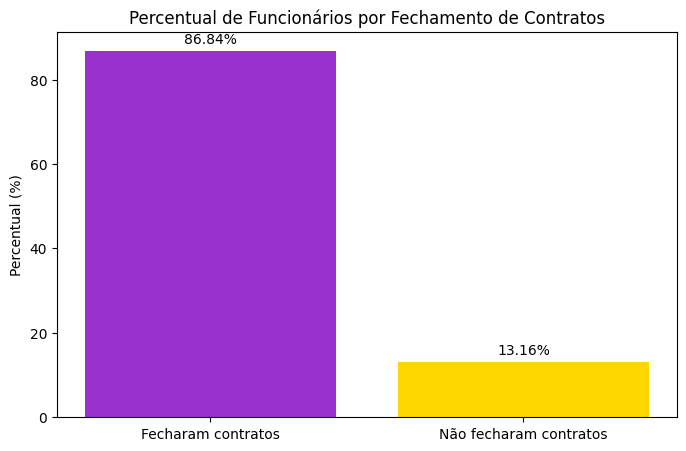

In [8]:
# 1. Contagem do total de funcionários da empresa
total_funcionarios = len(cadastro_funcionarios_df)
print("O total de funcionários da empresa é: {}".format(total_funcionarios))
print("-" * 34)
# 2. Contagem de quantos funcionários fecharam pelo menos um contrato
funcionarios_que_fecharam_contrato = base_serviços_df["ID Funcionário"].nunique()
print("A quantidade funcionários distintos que já fecharam contrato é: {}".format(funcionarios_que_fecharam_contrato))
print("-" * 34)
# 3. Cálculo do percentual
percentual_contratos_fechados = funcionarios_que_fecharam_contrato / total_funcionarios
print("Percentual de funcionários que fecharam contrato: {:.2%}".format(percentual_contratos_fechados))

#Criação do Gráfico
# 1. Preparando os valores para a escala do gráfico (0 a 100)
func_fecharam_percentual = percentual_contratos_fechados * 100
func_nao_fecharam_percentual = (1 - percentual_contratos_fechados) * 100

# 2. Organizando os eixos: Eixo X (horizontal:rótulos) e Eixo Y (vertical:valores)
rotulos_x = ["Fecharam contratos", "Não fecharam contratos"]
valores_y = [func_fecharam_percentual, func_nao_fecharam_percentual]

# 3. Criando o desenho das barras
plt.figure(figsize=(8,5))
barras = plt.bar(rotulos_x, valores_y, color=["darkorchid", "gold"])

# 4. Inserindo os números acima das barras
plt.bar_label(barras, fmt='%.2f%%', padding=3)

# 5. Dando Título ao Gráfico 
plt.title("Percentual de Funcionários por Fechamento de Contratos")
plt.ylabel("Percentual (%)") # Nome da escala vertical

# 6. Exibindo o gráfico pronto
plt.show()

### Conclusão da Análise:

- Por meio do cálculo e da visualização gráfica, observa-se que a grande maioria da equipe (86,84%) está ativamente convertendo serviços em contratos.
- Esse indicador demonstra um alto nível de produtividade comercial, permitindo à gestão focar esforços de treinamento ou suporte na parcela de 13,16% que ainda não atingiu essa marca, otimizando assim o desempenho organizacional global.

### 7) Total de contratos que cada área da empresa já fechou
O objetivo desta etapa é identificar quais áreas da empresa estão liderando o volume de contratos fechados. Para isso, realizo as seguintes operações:

1. **Integração de Dados**: Aplico o método `.merge()` para cruzar a Base de Serviços com o Cadastro de Funcionários utilizando a coluna do **"ID Funcionário"** como ligação. Isso gera o dataframe servicos_com_area_df, permitindo associar cada serviço prestado à área específica do funcionário que o realizou.

2. **Contagem dos contratos por área**: Utilizo a função `.value_counts()` na coluna de setores para contar a frequência de contratos em cada área, gerando automaticamente um ranking de produtividade por setor.

3. **Criação de um DataFrame limpo**: Para garantir uma leitura direta, utilizo o método `.reset_index()` para transformar o resultado da contagem em uma tabela(DataFrame) organizada. 
    - Em seguida, aplico a função `.rename()` apenas na coluna de valores para nomeá-la como **Quantidade de Contratos**, mantendo o nome original da coluna **Area** conforme extraído da base de dados.

4. **Visualização Gráfica**: Apresento os resultados em um gráfico de barras para facilitar a comparação visual entre os diferentes departamentos da organização.

Visualização da Base de Serviços com a coluna Area incorporada:


,Codigo do Servico,ID Funcionário,ID Cliente,Tempo Total de Contrato (Meses),Area
0,OS0001,67,1,14,Financeiro
1,OS0002,17,2,12,Logística
2,OS0003,116,4,14,Logística
3,OS0004,37,5,8,Financeiro
4,OS0005,130,6,8,Comercial
...,...,...,...,...,...
232,OS0233,111,315,4,Operações
233,OS0234,124,316,8,Comercial
234,OS0235,72,317,6,Logística
235,OS0236,90,319,14,Administrativo


,Area,Quantidade de Contratos
0,Administrativo,63
1,Operações,48
2,Comercial,44
3,Financeiro,42
4,Logística,40


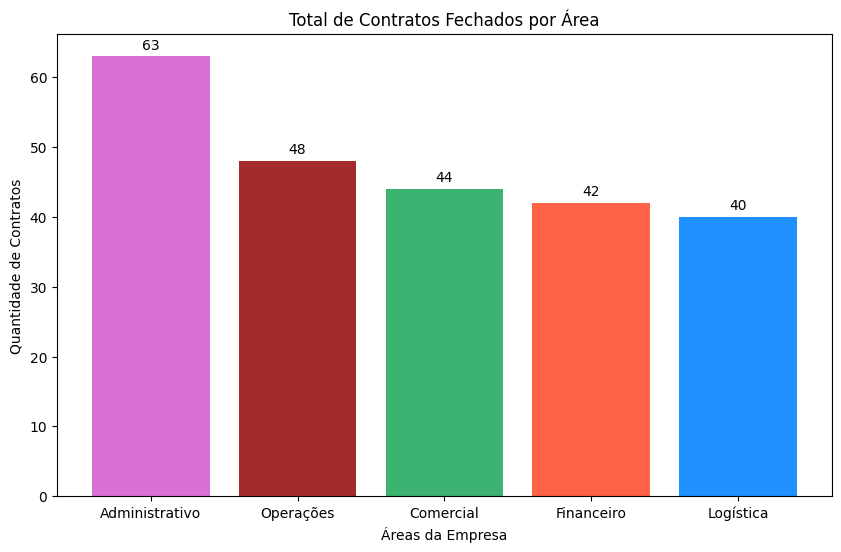

In [9]:
# 1. Integração dos DataFrame 
servicos_com_area_df = base_serviços_df.merge(cadastro_funcionarios_df[["ID Funcionário", "Area"]], on='ID Funcionário')
print("Visualização da Base de Serviços com a coluna Area incorporada:")
display(servicos_com_area_df)

#2. Contagem e 3. Criação de um DataFrame limpo com a reorganização dos dados
tabela_contratos_area = servicos_com_area_df["Area"].value_counts().reset_index()
tabela_contratos_area = tabela_contratos_area.rename(columns={"count": "Quantidade de Contratos"})

# Exibindo a tabela criada organizadamente para conferir
display(tabela_contratos_area)

# 4. Visualização Gráfica
plt.figure(figsize=(10, 6))
grafico_area = plt.bar(tabela_contratos_area["Area"], tabela_contratos_area["Quantidade de Contratos"], color=["orchid", "brown", "mediumseagreen", "tomato", "dodgerblue"])

# Adicionando os números em cima das barras para precisão
plt.bar_label(grafico_area, padding=3)

plt.title("Total de Contratos Fechados por Área")
plt.xlabel("Áreas da Empresa") # Nome da escala horizontal
plt.ylabel("Quantidade de Contratos")  # Nome da escala vertical
plt.show()

### Conclusão da Análise por Área:

- Ao observar os resultados, fica claro que a **área Administrativa** é a que possui o maior volume de trabalho finalizado, com 63 contratos.

- As **áreas de Operações e Comercial** vêm logo em seguida, mantendo um ritmo de produção muito próximo entre si.

- Já a **área da Logística** apresenta a menor quantidade de fechamentos (40). Essa informação é importante para a empresa entender como a demanda está distribuída e decidir se algum setor precisa de mais apoio ou mais funcionários para equilibrar os números.

### 8) Total de Funcionários por Área

Nesta etapa, o objetivo é mapear a estrutura da empresa, identificando a quantidade de funcionários alocados em cada área. 
- Isso permite uma visão clara da estrutura organizacional, sobretudo para comparar se as áreas com mais contratos são, de fato, as que possuem mais funcionários. Para chegar a este resultado, sigo estes passos:

1. **Contagem de Funcionários**: Utilizo a função `.value_counts()` diretamente na coluna "Area" do dataframe *cadastro_funcionarios_df* para contabilizar o total de profissionais por área.

2. **Organização dos Dados com a Criação de um Dataframe**: Aplico o método `.reset_index()` para converter o resultado da contagem em um **novo DataFrame** estruturado em duas colunas.

3. **Renomeação**: Aplico a função `.rename()` apenas na coluna *"count"* para renomeá-la como **Total de Funcionários por Área**, mantendo o nome original da coluna **Area** conforme extraído da base de dados, garantindo clareza na leitura da tabela final.

4. **Visualização Gráfica**: Para facilitar a comparação visual do tamanho das equipes entre os diferentes departamentos, apresento os resultados em um **gráfico de barras horizontais**.

,Area,count
0,Administrativo,26
1,Comercial,26
2,Operações,23
3,Logística,21
4,Financeiro,18


,Area,Total de Funcionários por Área
0,Administrativo,26
1,Comercial,26
2,Operações,23
3,Logística,21
4,Financeiro,18


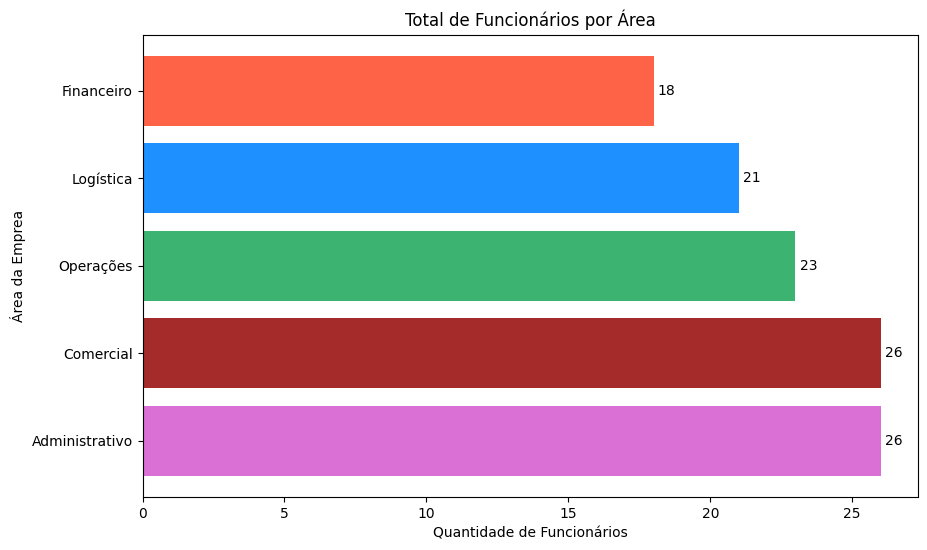

In [13]:
 # Contagem dos dados e organização com criação do Dataframe com duas colunas:
total_funcionarios_por_area_df = cadastro_funcionarios_df["Area"].value_counts().reset_index()
display(total_funcionarios_por_area_df)

# Renomando apenas a coluna 'count' para 'Total de Funcionários'
total_funcionarios_por_area_df = total_funcionarios_por_area_df.rename(columns={"count": "Total de Funcionários por Área"})
# Exibo a tabela pronta para conferir se a renomeação foi feita corretamente.
display(total_funcionarios_por_area_df)

# Visualização Gráfica (Barras Horizontais)
# Criando as barras horizontais (plt.barh)
plt.figure(figsize=(10, 6))
grafico_func_por_area = plt.barh(total_funcionarios_por_area_df["Area"], total_funcionarios_por_area_df["Total de Funcionários por Área"], color=["orchid", "brown", "mediumseagreen", "dodgerblue", "tomato"])

# Adicionando os números ao lado das barras
plt.bar_label(grafico_func_por_area, padding=3)

plt.title("Total de Funcionários por Área")
plt.xlabel("Quantidade de Funcionários")  # Nome da escala horizontal
plt.ylabel("Área da Emprea")  # Nome da escala vertical
plt.show()

### Conclusão da Estrutura de Funcionários

- Por meio da visualização gráfica, evidenciamos que a força de trabalho está concentrada principalmente nas áreas Administrativa e Comercial, que contam com 26 funcionários cada.
- O setor Financeiro apresenta a estrutura mais enxuta da organização, com apenas 18 funcionários.
- Cruzando esses dados com a etapa anterior, notamos que a liderança do setor Administrativo em contratos fechados (63) é coerente com o tamanho da sua equipe, indicando um equilíbrio entre o número de pessoas e o volume de entregas.

### 9) Análise de Produtividade e Participação por Área

Nesta etapa, o objetivo é aprofundar o entendimento sobre a eficiência de cada área da empresa, identificando a contribuição percentual de cada área e a taxa de produtividade por funcionário. Para chegar a este resultado, realizo as seguintes operações:

1. **Integração das Dados**: Aplico o método `.merge()` para unir as duas tabelas criadas anteriormente **(Contratos por Área e Total Funcionários por Área)**, utilizando a coluna do **Area** como ligação. Isso cria uma base única onde temos, lado a lado, o volume de trabalho e o tamanho da equipe.

2. **Cálculo da Produtividade**: Crio uma nova coluna denominada **"Produtividade"** e realizo uma **operação de divisão** entre as *colunas de Quantidade de Contratos e o Total de Funcionários*. Ao final, aplico a função `.round(2)` para limitar o resultado a duas casas decimais, garantindo uma leitura limpa da média de entregas por profissional em cada área.

3. **Cálculo de Participação (%)**: Utilizo a função `.sum()` para somar todos os contratos da *coluna Quantidade de Contratos*.  Com esse total, calculo o percentual, dividindo o valor de cada área pelo total geral e multiplicando por 100, para evidenciar a relevância de cada área no todo.

4. **Visualização Gráfica**: Apresento os resultados em um **Gráfico de Pizza** (usando plt.pie), permitindo uma leitura rápida da distribuição de força da organização.

O total de contratos fechados pela empresa foi de: 237


,Area,Quantidade de Contratos,Total de Funcionários por Área,Produtividade,Participação %
0,Administrativo,63,26,2.42,26.58
1,Operações,48,23,2.09,20.25
2,Comercial,44,26,1.69,18.57
3,Financeiro,42,18,2.33,17.72
4,Logística,40,21,1.90,16.88


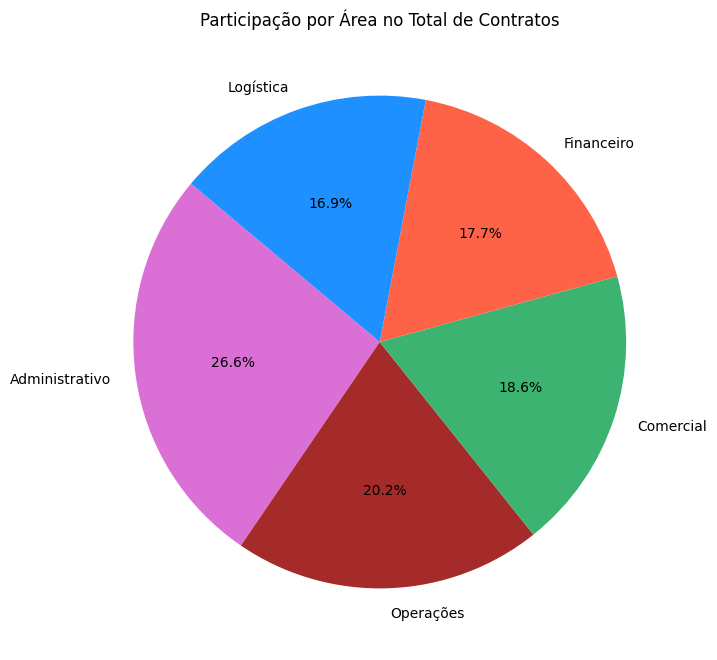

In [15]:
# 1. Integração dos Dados (Unindo as duas tabelas já criada usando a coluna "Area" como ligação)
# tabela_contratos_area (do Passo 7) + total_funcionarios_por_area_df (do Passo 8)
tabela_produtividade = tabela_contratos_area.merge(total_funcionarios_por_area_df, on="Area")

# 2. Cálculo da Produtividade (Contratos por Funcionários)
tabela_produtividade["Produtividade"] = (tabela_produtividade["Quantidade de Contratos"] / tabela_produtividade["Total de Funcionários por Área"]).round(2)

# 3. Cálculo de Participação % (Quanto cada área representa no todo)
total_geral_contratos = tabela_produtividade["Quantidade de Contratos"].sum()
print("O total de contratos fechados pela empresa foi de: {}".format(total_geral_contratos))
tabela_produtividade["Participação %"] = ((tabela_produtividade["Quantidade de Contratos"] / total_geral_contratos) * 100).round(2)

# Exibindo a tabela mestre para conferir se as colunas novas apareceram
display(tabela_produtividade)

# 4. Visualização Gráfica (Gráfico de Pizza)
plt.figure(figsize=(8, 8))
# Usamos a coluna de Participação para o gráfico e a coluna Area para as legendas
plt.pie(tabela_produtividade["Participação %"], labels=tabela_produtividade["Area"], autopct='%1.1f%%', 
        colors=["orchid","brown", "mediumseagreen", "tomato", "dodgerblue"], startangle=140)

plt.title("Participação por Área no Total de Contratos")
plt.show()

### Conclusão da Análise de Produtividade

Mediante a visualização gráfica do gráfico de pizza ficou evidenciado que determinadas áreas, mesmo com um quadro menor de funcionários, apresentam uma maior eficiência relativa, indicando a presença de boas práticas internas ou uma maior especialização das equipes.

- Ao analisar a Participação por Área, observamos que a **área Administrativa** lidera o volume geral, sendo responsável por 26,6% do total de contratos da empresa.

- No que tange à Produtividade, a **área Financeira** se destaca como o mais eficiente, apresentando a maior taxa de entregas por funcionário, seguido de perto pela área de Operações.

- A **área Comercial**, apesar de possuir uma das maiores equipes (26 funcionários), apresenta uma taxa de produtividade inferior à de Operações, o que corrobora a ideia de que o tamanho do time não é o único fator determinante para o volume de fechamentos.

### Insight e Recomendação

- **Insight**: Os dados revelam uma disparidade na eficiência entre as áreas. Áreas com menos funcionários, como Financeiro e Operações, conseguem manter um ritmo de produção por indivíduo superior ao de setores com maior contingente.

- **Recomendação**: Sugere-se realizar uma investigação detalhada nos processos internos das áreas de Financeiro e Operações para identificar e documentar as metodologias aplicadas. O objetivo é verificar a viabilidade de replicar essas práticas para otimizar a performance dos setores com produtividade inferior, como o Comercial e Logística.

### 10) Identificação e Ranking dos Top Performers Individuais

Com base nos resultados consolidados na tabela_produtividade (Passo 9), cujo foco recaía na análise da produtividade média por área, esta etapa visa identificar os colaboradores com melhor desempenho individual em fechamento de contratos. 
- Salienta-se que este mapeamento é fundamental para a gestão estratégica de talentos e para o compartilhamento de metodologias de sucesso entre as equipes.
- Para isso, sigo as seguintes operações:

1. **Agrupamento por Colaborador**: Utilizo a função `.groupby()` diretamente no DataFrame servicos_com_area_df (*gerada no Passo 7*) para destacar cada funcionário e sua respectiva área.

2. **Contagem e Renomeação**: Aplico o método `.size()` para contar quantos contratos cada ID fechou e, em seguida, utilizo o `.rename()` para batizar essa contagem como **"Qtde de Contratos Fechados"**, garantindo clareza técnica.

3. **Criação do Ranking**: Com o método `.sort_values()` ordeno a lista de colaboradores em ordem decrescente pela quantidade de contratos fechados.

4. **Filtragem do Top Performers**: Aplico a função `.head(5)` para extrair e exibir *apenas os 5 profissionais* com melhor desempenho para análise detalhada.

In [12]:
# 1. Agrupamento por Colaborador: Unindo ID e Área para destacar cada perfil
# Uso a tabela 'servicos_com_area_df' (gerada no seu Passo 7)
ranking_individual_df = servicos_com_area_df.groupby(["ID Funcionário", "Area"]).size().reset_index()

# 2. Contagem e Renomeação: Transformando a contagem em uma coluna com nome profissional
ranking_individual_df = ranking_individual_df.rename(columns={0: "Qtde de Contratos Fechados"})

# 3. Criação do Ranking: Ordenando apenas por contratos, do maior para o menor
ranking_individual_df = ranking_individual_df.sort_values(by="Qtde de Contratos Fechados", ascending=False)

# 4. Filtragem do Top Performers: Selecionando apenas os 5 profissionais de maior destaque
top_5_vendedores = ranking_individual_df.head(5)

# Exibição do resultado final dos 5 funcionários com mais contratos fechados
print("--- Ranking Top 5 Colaboradores ---")
display(top_5_vendedores)

--- Ranking Top 5 Colaboradores ---


,ID Funcionário,Area,Qtde de Contratos Fechados
33,47,Operações,6
27,37,Financeiro,5
2,4,Administrativo,5
59,84,Logística,5
19,27,Financeiro,4


### Insight e Conclusão
O ranking dos Top 5 Colaboradores revela um contraste fundamental quando comparado à distribuição total de funcionários por área:

- **Liderança da Produtividade**: A **área de Operações** lidera a lista com o colaborador de melhor desempenho absoluto (ID 47, com 6 contratos fechados).

- **Eficiência Concentrada**: Áreas como Financeiro e Logística (que possuem menos funcionários) garantem posições de destaque no Top 5. Isso sugere que as altas taxas de produtividade dessas áreas, vistas no Passo 9, são impulsionadas por indivíduos de altíssimo desempenho.

⚠️ **Alerta Estratégico**: A área Comercial, que é a mais numerosa da empresa (26 pessoas) e tem como *core business* as vendas, está totalmente ausente do ranking dos 5 melhores.

- *Diagnóstico*: Esta ausência reforça que a baixa produtividade do Comercial não é somente uma média baixa, mas sim uma falta de talentos de alto impacto ou uma necessidade urgente de reestruturação de processos.

### 💡 Recomendação Final
- Para mitigar a baixa produtividade na área Comercial, sugere-se uma *análise comparativa (benchmarking) detalhada* dos métodos e pipelines de vendas usados pelo Top Performer de Operações (ID 47) e pelos destaques do Financeiro (ID 37), para identificar padrões de sucesso que possam ser replicados para otimizar o desempenho de toda a equipe Comercial.

### 11) Calculando o Ticket (faturamento) Médio Mensal dos Contratos por Cliente

O Ticket Médio é um indicador financeiro que pode ser aplicado a diversas periodicidades. Nesta análise, o foco será o **Ticket Médio Mensal,** que representa a média de receita gerada mensalmente por cada contrato da empresa. 
- O objetivo de calculá-lo é estabelecer um parâmetro de comparação: ele nos diz se, em média, nossos contratos são de alto ou baixo valor, servindo como um KPI (Indicador de Desempenho) para medir a saúde financeira das vendas.

Passo a Passo da Execução:

- 1. **Identificação da Coluna**: Seleciono a coluna **"Valor Contrato Mensal"** do DataFrame *(cadastro_clientes_df)*, por conter os valores brutos de cada contrato mensal realizado.

- 2. **Cálculo da Média**: Utilizo a função `.mean()` do **Pandas** para somar todos os valores e dividi-los pela quantidade total de contratos, resultando na média aritmética.

- 3. **Formatação**: Formato o resultado final para o padrão monetário brasileiro (R$), para facilitar a leitura e a análise financeira.

In [15]:
ticket_medio_mensal = cadastro_clientes_df["Valor Contrato Mensal"].mean()
print("O Faturamento Médio Mensal dos Contratos por Cliente da Empresa é de: R${:,.2f}".format(ticket_medio_mensal))

O Faturamento Médio Mensal dos Contratos por Cliente da Empresa é de: R$2,502.56


### Insight Financeiro
Com base no Ticket Médio apurado, podemos extrair análises fundamentais para compreender a qualidade das vendas e o posicionamento de mercado da empresa sob dois prismas estratégicos:

- **Primeiro, como um parâmetro de crescimento**, onde o valor de R$ 2.502,56 estabelece agora uma base comparativa para futuros contratos. Qualquer novo fechamento realizado abaixo deste patamar estará "puxando a média para baixo", enquanto contratos acima deste valor elevarão o faturamento médio por cliente.

- **Segundo, como um indicador de qualidade operacional**, pois ao correlacionar este Ticket Médio com a **produtividade das áreas**, encontrada no `Passo 9`, e com o **ranking individual de desempenho de vendas**, visto no `Passo 10`, a empresa consegue avaliar se tanto as áreas com **alta entrega** (como *Logística ou Financeira*) quanto funcionários com maior volume de entrega (*ex: ID 47*) estão trazendo contratos com valores financeiros relevantes ou se o foco está recaindo apenas em volume com contratos de valor menor..

### 12) Análise da Qualidade Financeira dos Contratos por Área
- **Objetivo**: Verificar se as áreas que apresentam maior quantidade de contratos fechados (como a área de Operações) também conseguem manter um padrão de contratos de alto valor, ou se o seu desempenho está concentrado em negócios de baixo valor financeiro (ticket baixo).

Para isso, realizarei as seguintes etapas de código:

1. **Integração das Dados 1**: Aplico o método `.merge()` para unir o DataFrame *(base_serviços_df)* ao DataFrame *(cadastro_funcionarios_df)* utilizando a coluna do **ID Funcionario** como ligação para identificar a qual área cada contrato pertence. Ademais, utilizo o parâmetro `how="left"` como camada de segurança para garantir que todos os contratos da base original sejam mantidos, mesmo que haja alguma inconsistência no cadastro de funcionários.

2. **Integração das Dados 2**: Novamente, utilizo a função `.merge()` para conectar o resultado anterior ao DataFrame *cadastro_clientes_df*, utilizando o **ID Cliente**, dessa vez, como chave para trazer a informação financeira de cada contrato constatata na coluna **Valor Contrato Mensal**. Reforço o uso do `how="left"` para assegurar que o faturamento total seja preservado e o cálculo final da média seja exato.

3. **Filtragem de Colunas:**: Seleciono apenas as colunas que interessam para esta análise (Area e Valor Contrato Mensal), eliminando dados desnecessários e focando, exclusivamente, na performance financeira por setor.

4. **Cálculo da Média por Área**: Utilizo as funções `.groupby()` e `.mean()` para calcular o **Ticket Médio segmentado por área**, permitindo a comparação direta entre o desempenho financeiro de cada departamento. Complemento a linha do código com o `.round(2)`para manter o **padrão monetário** de duas casas decimais e aplico ainda o `.reset_index()` para organizar o resultado final em formato de tabela (DataFrame), transformando os grupos em colunas comuns.

In [19]:
# 1. Integração de Dados 1: Unindo base de serviços com funcionários para identificar a 'Area'
ticket_area_df = base_serviços_df.merge(cadastro_funcionarios_df[['ID Funcionário', 'Area']], on="ID Funcionário", how="left")

# 2. Integração de Dados 2: Conectando o resultado com o cadastro de clientes para trazer o 'Valor Contrato Mensal'
ticket_area_df = ticket_area_df.merge(cadastro_clientes_df[['ID Cliente', 'Valor Contrato Mensal']], on="ID Cliente", how="left")

# 3. Filtragem de Colunas e Conferência Visual:
ticket_area_df = ticket_area_df[['Area', 'Valor Contrato Mensal']]
display(ticket_area_df)

# 4. Cálculo da Média por Área: 
ranking_ticket_area = ticket_area_df.groupby("Area")["Valor Contrato Mensal"].mean().round(2).reset_index()

# Renomeando a coluna final para o nome técnico correto
ranking_ticket_area = ranking_ticket_area.rename(columns={"Valor Contrato Mensal": "Ticket Médio por Área"})

# Exibição do resultado
print("--- Ticket Médio (Valor) dos Contratos por Área ---")
display(ranking_ticket_area)

,Area,Valor Contrato Mensal
0,Financeiro,540
1,Logística,1260
2,Logística,2520
3,Financeiro,3510
4,Comercial,2340
...,...,...
232,Operações,1575
233,Comercial,3690
234,Logística,2385
235,Administrativo,4185


--- Ticket Médio (Valor) dos Contratos por Área ---


,Area,Ticket Médio por Área
0,Administrativo,2512.14
1,Comercial,2466.82
2,Financeiro,2392.50
3,Logística,2291.62
4,Operações,2477.81


### Conclusão dos Resultados
- Com base no desenvolvimento desta etapa, os dados revelam não apenas o valor financeiro médio que cada área gera por contrato (**Ticket Médio por Área**), mas também comprovam que **apenas a área Administrativa** opera com um valor de contrato superior à média global da empresa (R$ 2.502,56). As demais áreas — Comercial, Operações, Financeiro e Logística — apresentam resultados financeiros por contrato abaixo desse patamar, sendo a **Logística** a área com o menor desempenho médio (R$ 2.291,62).

| Área | Ticket Médio por Área | Comparação com a Média da Empresa |
| :--- | :--- | :--- |
| **Administrativo** | R$ 2.512,14 | **Acima** |
| **Comercial** | R$ 2.466,82 | Abaixo |
| **Operações** | R$ 2.477,81 | Abaixo |
| **Financeiro** | R$ 2.392,50 | Abaixo |
| **Logística** | R$ 2.291,62 | Abaixo |

### Insights e Recomendações Estratégicas:
A partir da conclusão extraída desta análise, é possível definir direcionamentos importantes para o planejamento estratégico da empresa, tais como:

- **Manter o equilíbrio no Setor Administrativo**: Esta área demonstra ser o setor mais equilibrado da companhia, conseguindo sustentar um padrão de contratos de alto valor que impulsiona a média geral para cima.

- **Aproveitar a oportunidade de revisão de metas**: O cenário atual indica a necessidade de a diretoria revisar as estratégias de negociação das áreas de **Logística** e **Financeiro**, visando elevar o patamar desses contratos para que se alinhem à média global.

- **Reavaliar o foco em Qualidade vs. Quantidade**: É preciso analisar se a alta produção de áreas como **Operações** não está prejudicando a captação de negócios com maior valor financeiro, priorizando o volume em detrimento do ticket médio.

### 🌟 Resumo Executivo: Consolidação do Faturamento e Performance Operacional
- Este projeto de análise de dados foi desenvolvido com o propósito de avaliar a eficiência operacional e a qualidade financeira da empresa, cruzando dados de produtividade por área com o valor real dos contratos fechados. A intenção principal foi identificar não apenas onde se fecha mais negócios, mas onde se gera o melhor retorno para a empresa.


**1. 📊 Panorama Geral e Descobertas-Chave:**
- A partir do processamento das bases de dados, consolidamos os seguintes pontos fundamentais:

    - **Faturamento Global**: Identificamos o faturamento total da empresa, estabelecendo uma base sólida para entender o tamanho da operação.

    - **Contradição da Produtividade**: A análise de participação revelou que a `área Administrativa` lidera o volume de contratos com 63 no total (26,6% do total). No entanto, identificamos que **setores com equipes menores**, como Financeiro (18 pessoas) e Operações (23 pessoas), **demonstraram maior eficiência relativa**, mantendo um ritmo de produção por indivíduo superior (produtividades de 2.33 e 2.09, respectivamente).

    - **O Ponto de Atenção na Área Comercial:**: Embora detenha um dos maiores quadros de funcionários da empresa (26 colaboradores), a `área Comercial` apresentou a menor taxa de produtividade (1.69). Esta subperformance é ratificada pelo **Ranking de Top Performers**, no qual `o Comercial` não obteve **nenhum representante entre os 5 melhores**, evidenciando uma falha crítica na conversão de vendas quando comparado ao Administrativo, que opera com o mesmo número de pessoas.
    
    - **Qualidade Financeira**: O `Ticket Médio da empresa é de R$ 2.502,56`. A análise comprovou que `apenas a área Administrativa` opera acima desse patamar, com o valor de faturamento de R$ 2.512,14. Todas as demais áreas apresentam valores inferiores, a exemplo da `área de Operações` que, apesar do alto volume de entregas, mantém um um Ticket Médio de R$ 2.477,81, o que reforça a necessidade de reavaliar se a alta produção não está ocorrendo em detrimento do valor financeiro dos contratos.


**2. 🚀 Ações Recomendadas (O que implementar):**
- Com base no diagnóstico acima, apresento as seguintes propostas de melhoria:

    - **Implementar um programa de Benchmarking Interno**, uma prática de gestão para comparar processos, métodos e resultados utilizando a `área Administrativa` como modelo de eficiência financeira e as áreas de Financeiro e Operações como referências de agilidade processual para elevar a performance dos demais setores.
    
    - **Realizar Diagnóstico e Recalibragem da Área Comercial**: Investigar as causas da subperformance da `área Comercial` - que mesmo sendo o mais numeroso, juntamente com a área Administrativa, não obteve representantes no *Top 5 de Performance* -  e instituir treinamentos focados em **elevar o Ticket Médio**, alinhando a produtividade dos 26 colaboradores às expectativas de faturamento.

    - **Instituir a Revisão de Metas em Operações**: Aproveitar a alta produtividade já existente para priorizar negócios de maior relevância financeira, visando elevar o seu Ticket Médio para que este ultrapasse a média global da companhia.
    


**3. 📈 Impacto Esperado:**
- Ao seguir estas recomendações, a empresa poderá vivenciar:

    - **Elevação do Ticket Médio Geral**: Ao alinhar as áreas de menor valor à média global, haverá um aumento direto na margem de lucro sem a necessidade de novas contratações.

    - **Otimização da Força de Vendas**: A recalibragem da área Comercial permitirá que o grande volume de colaboradores (26 pessoas) seja convertido em resultados reais, garantindo que a alta produtividade venha acompanhada de relevância financeira.
    
    - **Padronização da Qualidade**: A redução da disparidade financeira entre as áreas criará um fluxo de caixa mais previsível e saudável para a companhia.